![Databricks Academy](https://files.training.databricks.com/binder/prod_main/automated-deployment-with-declarative-automation-bundles-en_us-2.4.0/images/20260828T161450Z/Automated Deployment with Declarative Automation Bundles/Includes/images/common/db-academy.png)

# Lecture - Deploying Databricks Projects

## Overview

In this lecture, you will review what makes up a typical Databricks project, the goal of the CI/CD journey from development to production, the tools available to orchestrate that journey, and how Declarative Automation Bundles (DABs) simplify deploying to multiple environments.

## Learning Objectives

By the end of this lecture, you will be able to:
1. **Describe** the components of a Databricks project: code, resources, and execution environment.
2. **Explain** the CI/CD journey across development, staging, and production environments.
3. **Compare** the options for orchestrating deployment: the UI, the REST API/SDK, and Terraform.
4. **Explain** how Declarative Automation Bundles (DABs) simplify deploying to multiple environments.

## A. Typical Databricks Projects

### A1. What Makes Up a Databricks Project?

Every Databricks project, from a simple report to a full MLOps pipeline, is built from the same three kinds of **components**. Click each tab to explore, then read on for what a project *produces* and how the deliverable drives the choice.
<div style="max-width:1100px;margin:0 auto;font-family:sans-serif;">
<style>
.tb1-tabbar { display:flex; border-bottom:2px solid #EEEDE9; flex-wrap:wrap; }
.tb1-tab { padding:10px 20px; border:none; border-bottom:3px solid transparent; background:none; font-size:14pt; font-weight:bold; color:#888; cursor:pointer; margin-bottom:-2px; }
.tb1-tab-active-1 { color:#4299E0; border-bottom-color:#4299E0; }
.tb1-tab-active-2 { color:#00A972; border-bottom-color:#00A972; }
.tb1-tab-active-3 { color:#FFAB00; border-bottom-color:#FFAB00; }
.tb1-panel { display:none; margin-top:16px; } .tb1-panel-active { display:block; }
</style>
<div class="tb1-tabbar"><button class="tb1-tab" onclick="tb1Show(1)">Code</button><button class="tb1-tab" onclick="tb1Show(2)">Resources</button><button class="tb1-tab" onclick="tb1Show(3)">Execution Environment</button></div>
<div class="tb1-panel"><div style="background:#F9F7F4;border-radius:8px;box-shadow:0 2px 8px rgba(27,49,57,0.06);border-top:6px solid #4299E0;padding:22px 24px;"><div style="font-size:16pt;font-weight:700;color:#0b2026;margin-bottom:8px;">Code</div><p style="font-size:14pt;color:#0b2026;">The logic that produces your data products.</p><div style="display:flex;flex-wrap:wrap;gap:8px;"><span style="background:rgba(255,95,70,0.08);border-radius:16px;padding:6px 16px;font-size:14pt;color:#0b2026;">Notebooks</span><span style="background:rgba(255,95,70,0.08);border-radius:16px;padding:6px 16px;font-size:14pt;color:#0b2026;">Python .whl</span><span style="background:rgba(255,95,70,0.08);border-radius:16px;padding:6px 16px;font-size:14pt;color:#0b2026;">JAR</span><span style="background:rgba(255,95,70,0.08);border-radius:16px;padding:6px 16px;font-size:14pt;color:#0b2026;">dbt</span><span style="background:rgba(255,95,70,0.08);border-radius:16px;padding:6px 16px;font-size:14pt;color:#0b2026;">SQL / Python / R</span></div></div></div>
<div class="tb1-panel"><div style="background:#F9F7F4;border-radius:8px;box-shadow:0 2px 8px rgba(27,49,57,0.06);border-top:6px solid #00A972;padding:22px 24px;"><div style="font-size:16pt;font-weight:700;color:#0b2026;margin-bottom:8px;">Resources</div><p style="font-size:14pt;color:#0b2026;">The Databricks objects your code runs on.</p><div style="display:flex;flex-wrap:wrap;gap:8px;"><span style="background:rgba(255,95,70,0.08);border-radius:16px;padding:6px 16px;font-size:14pt;color:#0b2026;">Lakeflow Jobs / Workflows</span><span style="background:rgba(255,95,70,0.08);border-radius:16px;padding:6px 16px;font-size:14pt;color:#0b2026;">MLflow Tracking Server &amp; Registry</span><span style="background:rgba(255,95,70,0.08);border-radius:16px;padding:6px 16px;font-size:14pt;color:#0b2026;">Spark Declarative Pipelines (SDP)</span></div></div></div>
<div class="tb1-panel"><div style="background:#F9F7F4;border-radius:8px;box-shadow:0 2px 8px rgba(27,49,57,0.06);border-top:6px solid #FFAB00;padding:22px 24px;"><div style="font-size:16pt;font-weight:700;color:#0b2026;margin-bottom:8px;">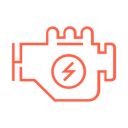 Execution Environment</div><p style="font-size:14pt;color:#0b2026;">Where and how the project runs.</p><div style="display:flex;flex-wrap:wrap;gap:8px;"><span style="background:rgba(255,95,70,0.08);border-radius:16px;padding:6px 16px;font-size:14pt;color:#0b2026;">Databricks Workspace</span><span style="background:rgba(255,95,70,0.08);border-radius:16px;padding:6px 16px;font-size:14pt;color:#0b2026;">Unity Catalog</span><span style="background:rgba(255,95,70,0.08);border-radius:16px;padding:6px 16px;font-size:14pt;color:#0b2026;">Compute configuration(s)</span></div></div></div>
</div>
<script>
function tb1Show(n){var t=document.getElementsByClassName("tb1-tab"),p=document.getElementsByClassName("tb1-panel");
for(var i=0;i<t.length;i++){t[i].className="tb1-tab";p[i].className="tb1-panel";}
p[n-1].className="tb1-panel tb1-panel-active"; t[n-1].className="tb1-tab tb1-tab-active-"+n;}
window.addEventListener('load',function(){ tb1Show(1); });
</script>

<div style="max-width:1100px;margin:28px auto 0 auto;font-family:sans-serif;">
  <div style="font-size:15pt;font-weight:700;color:#0b2026;margin-bottom:10px;">Projects <span style="color:#00A972;">produce</span> a variety of data products</div>
  <div style="display:flex;flex-wrap:wrap;gap:8px;">
    <span style="background:rgba(0,169,114,0.10);border:1px solid #00A972;border-radius:16px;padding:6px 16px;font-size:14pt;color:#0b2026;">tables</span>
    <span style="background:rgba(0,169,114,0.10);border:1px solid #00A972;border-radius:16px;padding:6px 16px;font-size:14pt;color:#0b2026;">pipelines</span>
    <span style="background:rgba(0,169,114,0.10);border:1px solid #00A972;border-radius:16px;padding:6px 16px;font-size:14pt;color:#0b2026;">jobs</span>
    <span style="background:rgba(0,169,114,0.10);border:1px solid #00A972;border-radius:16px;padding:6px 16px;font-size:14pt;color:#0b2026;">machine learning models</span>
    <span style="background:rgba(0,169,114,0.10);border:1px solid #00A972;border-radius:16px;padding:6px 16px;font-size:14pt;color:#0b2026;">dashboards</span>
    <span style="background:rgba(0,169,114,0.10);border:1px solid #00A972;border-radius:16px;padding:6px 16px;font-size:14pt;color:#0b2026;">call external services</span>
    <span style="background:rgba(0,169,114,0.10);border:1px solid #00A972;border-radius:16px;padding:6px 16px;font-size:14pt;color:#0b2026;">etc.</span>
  </div>
</div>
<div style="max-width:1100px;margin:24px auto 0 auto;font-family:sans-serif;">
  <div style="font-size:15pt;font-weight:700;color:#0b2026;margin-bottom:10px;">The <span style="color:#FF5F46;">deliverable determines</span> the components</div>
  <div style="display:flex;gap:16px;flex-wrap:wrap;">
    <div style="flex:1 1 320px;background:#F9F7F4;border-radius:8px;border-left:6px solid #4299E0;padding:16px 18px;box-shadow:0 2px 8px rgba(27,49,57,0.06);"><div style="font-size:14.5pt;font-weight:700;color:#0b2026;margin-bottom:4px;">A simple report</div><div style="font-size:14pt;color:#0b2026;">might consist of a notebook running on single-node compute.</div></div>
    <div style="flex:1 1 320px;background:#F9F7F4;border-radius:8px;border-left:6px solid #98102A;padding:16px 18px;box-shadow:0 2px 8px rgba(27,49,57,0.06);"><div style="font-size:14.5pt;font-weight:700;color:#0b2026;margin-bottom:4px;">A full MLOps pipeline</div><div style="font-size:14pt;color:#0b2026;">would require MLflow, Feature Store, and Model Serving components.</div></div>
  </div>
</div>

##### EXPAND FOR ADDITIONAL NOTES

<details>

_Speaker notes:_

- Let's quickly recap the typical components of a Databricks project.
- First, a Databricks project consists of multiple components, including code, notebooks, Python files, Python wheel files, JARs, DBT, and more.
- It also includes an execution environment within one or more Databricks workspaces, along with specific compute configurations for processing.
- Lastly, the project may involve other Databricks resources, such as Lakeflow Jobs, MLflow, Spark Declarative Pipelines, and more.
- Next, a Databricks project typically produces a variety of data products, including tables, pipelines, models, jobs, dashboards, and more.
- Lastly, the deliverables of your project determine the components you'll need.
- For example, a simple report might include one or more notebooks running on a basic single-node compute.
- On the other hand, a full MLOps pipeline would require multiple components, such as MLflow, the Feature Store, model serving components, notebooks, and more.

</details>

### A2. Simple Example Project Components

A concrete example: the three component types mapped to a simple Databricks project. The workspace on the left holds the assets; the list on the right maps them to **code**, **resources**, and **execution environment**.
<div style="display:flex;align-items:center;gap:30px;justify-content:center;max-width:1100px;margin:0 auto;font-family:sans-serif;flex-wrap:wrap;">
  <div style="border:2px dashed #8A9BA8;border-radius:10px;padding:18px 22px;min-width:280px;">
    <div style="display:flex;align-items:center;gap:10px;font-size:18pt;font-weight:700;color:#0b2026;justify-content:center;margin-bottom:14px;">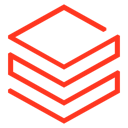 Workspace</div>
    <div style="background:#F6A192;color:#0b2026;font-weight:700;font-size:14pt;text-align:center;padding:10px 8px;border-radius:6px;margin-bottom:10px;">Notebooks</div>
    <div style="background:#F6A192;color:#0b2026;font-weight:700;font-size:14pt;text-align:center;padding:10px 8px;border-radius:6px;margin-bottom:10px;">Pipelines</div>
    <div style="background:#F6A192;color:#0b2026;font-weight:700;font-size:14pt;text-align:center;padding:10px 8px;border-radius:6px;margin-bottom:10px;">Jobs</div>
    <div style="background:#F6A192;color:#0b2026;font-weight:700;font-size:14pt;text-align:center;padding:10px 8px;border-radius:6px;margin-bottom:10px;">Unity Catalog</div>
    <div style="text-align:center;margin-top:8px;">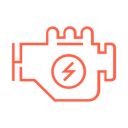</div>
  </div>
  <div style="font-size:40pt;color:#F6A192;line-height:1;">&rarr;</div>
  <div style="font-size:14pt;color:#0b2026;">
    <div style="font-weight:700;font-size:16pt;color:#4299E0;">Code</div>
    <ul style="margin:4px 0 14px 0;"><li>Python / SQL / R notebooks</li></ul>
    <div style="font-weight:700;font-size:16pt;color:#00A972;">Resources</div>
    <ul style="margin:4px 0 14px 0;"><li>Lakeflow Jobs</li><li>Spark Declarative Pipelines (SDP)</li></ul>
    <div style="font-weight:700;font-size:16pt;color:#FFAB00;">Execution Environment</div>
    <ul style="margin:4px 0 0 0;"><li>Databricks Workspace</li><li>Unity Catalog</li><li>Compute configuration(s)</li></ul>
  </div>
</div>

##### EXPAND FOR ADDITIONAL NOTES

<details>

_Speaker notes:_

- For example, a simple Data Engineering Databricks project could include notebooks, Spark Declarative Pipelines, a workflow, catalogs within Unity Catalog, and specific compute configurations for the project.

</details>

## B. The CI/CD Journey to Production

### B1. CI/CD Journey to Production

A project is promoted through **development**, **staging**, and **production**. Code moves via version control &mdash; a **pull request** into stage, a **release** into main &mdash; and each branch is deployed down into its own environment.
<div style="max-width:1120px;margin:0 auto;font-family:sans-serif;">
  <div style="border:1px solid #C4CDD2;border-radius:8px;padding:14px 18px;margin-bottom:6px;">
    <div style="font-weight:700;font-size:14pt;color:#0b2026;margin-bottom:10px;">Version Control</div>
    <div style="display:grid;grid-template-columns:1fr 1fr 1fr;align-items:center;text-align:center;">
      <div><span style="display:inline-flex;align-items:center;gap:6px;background:#fff;border:1px solid #DCE0E2;border-radius:6px;padding:5px 12px;font-size:13.5pt;color:#0b2026;">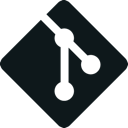dev</span></div>
      <div><div style="font-style:italic;color:#5E7077;">pull request &rarr;</div><span style="display:inline-flex;align-items:center;gap:6px;background:#fff;border:1px solid #DCE0E2;border-radius:6px;padding:5px 12px;font-size:13.5pt;color:#0b2026;">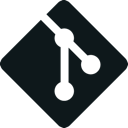stage</span></div>
      <div><div style="font-style:italic;color:#5E7077;">release &rarr;</div><span style="display:inline-flex;align-items:center;gap:6px;background:#fff;border:1px solid #DCE0E2;border-radius:6px;padding:5px 12px;font-size:13.5pt;color:#0b2026;">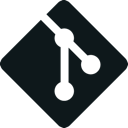main</span></div>
    </div>
  </div>
  <div style="display:grid;grid-template-columns:1fr 1fr 1fr;">
    <div><div style="text-align:center;margin:6px 0;">
  <div style="font-style:italic;font-weight:700;color:#0b2026;font-size:13pt;">Deploy</div>
  <div style="font-size:26pt;color:#0b2026;line-height:0.9;">&darr;</div>
</div></div><div><div style="text-align:center;margin:6px 0;">
  <div style="font-style:italic;font-weight:700;color:#0b2026;font-size:13pt;">Deploy</div>
  <div style="font-size:26pt;color:#0b2026;line-height:0.9;">&darr;</div>
</div></div><div><div style="text-align:center;margin:6px 0;">
  <div style="font-style:italic;font-weight:700;color:#0b2026;font-size:13pt;">Deploy</div>
  <div style="font-size:26pt;color:#0b2026;line-height:0.9;">&darr;</div>
</div></div>
  </div>
  <div style="display:grid;grid-template-columns:1fr 1fr 1fr;gap:16px;">
    <div style="background:#FBE3E0;border-radius:8px;padding:16px;">
  <div style="display:flex;align-items:center;gap:8px;margin-bottom:10px;">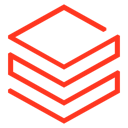<span style="font-weight:700;font-size:14pt;color:#0b2026;">development</span></div>
  <div style="background:#F6A192;color:#0b2026;font-weight:700;text-align:center;padding:8px;border-radius:5px;margin-bottom:8px;font-size:13.5pt;">Notebooks</div><div style="background:#F6A192;color:#0b2026;font-weight:700;text-align:center;padding:8px;border-radius:5px;margin-bottom:8px;font-size:13.5pt;">SDP</div><div style="background:#F6A192;color:#0b2026;font-weight:700;text-align:center;padding:8px;border-radius:5px;margin-bottom:8px;font-size:13.5pt;">Workflows</div><div style="background:#F6A192;color:#0b2026;font-weight:700;text-align:center;padding:8px;border-radius:5px;margin-bottom:8px;font-size:13.5pt;">Unity Catalog</div>
  <div style="background:rgba(255,255,255,0.55);border:1px solid rgba(0,0,0,0.08);border-radius:6px;padding:10px 12px;margin-top:4px;">
    <div style="font-weight:700;color:#0b2026;margin-bottom:4px;">Dev config:</div>
    <ul style="margin:0;padding-left:18px;font-size:13.5pt;color:#0b2026;"><li>Single node</li><li>Run as user</li><li>Use dev data and environment</li></ul>
  </div>
  <div style="text-align:center;margin-top:8px;">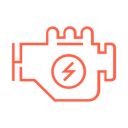</div>
</div>
    <div style="background:#FBEBCD;border-radius:8px;padding:16px;">
  <div style="display:flex;align-items:center;gap:8px;margin-bottom:10px;">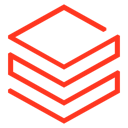<span style="font-weight:700;font-size:14pt;color:#0b2026;">staging</span></div>
  <div style="background:#F6A192;color:#0b2026;font-weight:700;text-align:center;padding:8px;border-radius:5px;margin-bottom:8px;font-size:13.5pt;">Notebooks</div><div style="background:#F6A192;color:#0b2026;font-weight:700;text-align:center;padding:8px;border-radius:5px;margin-bottom:8px;font-size:13.5pt;">SDP</div><div style="background:#F6A192;color:#0b2026;font-weight:700;text-align:center;padding:8px;border-radius:5px;margin-bottom:8px;font-size:13.5pt;">Workflows</div><div style="background:#F6A192;color:#0b2026;font-weight:700;text-align:center;padding:8px;border-radius:5px;margin-bottom:8px;font-size:13.5pt;">Unity Catalog</div>
  <div style="background:rgba(255,255,255,0.55);border:1px solid rgba(0,0,0,0.08);border-radius:6px;padding:10px 12px;margin-top:4px;">
    <div style="font-weight:700;color:#0b2026;margin-bottom:4px;">Staging config:</div>
    <ul style="margin:0;padding-left:18px;font-size:13.5pt;color:#0b2026;"><li><b>Serverless</b></li><li>Run as <b>service principal</b></li><li>Use staging data and environment</li></ul>
  </div>
  <div style="text-align:center;margin-top:8px;">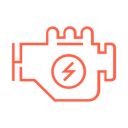</div>
</div>
    <div style="background:#D9EAD8;border-radius:8px;padding:16px;">
  <div style="display:flex;align-items:center;gap:8px;margin-bottom:10px;">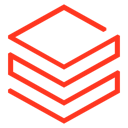<span style="font-weight:700;font-size:14pt;color:#0b2026;">production</span></div>
  <div style="background:#F6A192;color:#0b2026;font-weight:700;text-align:center;padding:8px;border-radius:5px;margin-bottom:8px;font-size:13.5pt;">Notebooks</div><div style="background:#F6A192;color:#0b2026;font-weight:700;text-align:center;padding:8px;border-radius:5px;margin-bottom:8px;font-size:13.5pt;">SDP</div><div style="background:#F6A192;color:#0b2026;font-weight:700;text-align:center;padding:8px;border-radius:5px;margin-bottom:8px;font-size:13.5pt;">Workflows</div><div style="background:#F6A192;color:#0b2026;font-weight:700;text-align:center;padding:8px;border-radius:5px;margin-bottom:8px;font-size:13.5pt;">Unity Catalog</div>
  <div style="background:rgba(255,255,255,0.55);border:1px solid rgba(0,0,0,0.08);border-radius:6px;padding:10px 12px;margin-top:4px;">
    <div style="font-weight:700;color:#0b2026;margin-bottom:4px;">Production config:</div>
    <ul style="margin:0;padding-left:18px;font-size:13.5pt;color:#0b2026;"><li><b>Serverless</b></li><li>Run as <b>service principal</b></li><li><b>Weekly</b> schedule</li></ul>
  </div>
  <div style="text-align:center;margin-top:8px;">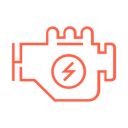</div>
</div>
  </div>
</div>

##### EXPAND FOR ADDITIONAL NOTES

<details>

_Speaker notes:_

- Let's take a look at a high-level CI/CD journey to production.
- To start, you'll want to have a version control strategy in place. For example, your strategy might include dev, stage, and main branches.
- From here, begin by deploying your Databricks project to the development environment. This allows you to test any changes or updates made to your project on development data, using specific development configurations.
- After completing development and creating a pull request into your stage branch, you will then deploy to the staging environment. This ensures testing of your project continues on new staging data with the appropriate staging configurations.
- Once both your development and staging environments have completed testing and passed all tests, you can deploy to your main or production branch. This will fully deploy your project to production, utilizing production data and the necessary production configurations.
- For development, we'll configure the environment to use single-node compute, as our data is small and doesn't require a large cluster. We'll run the project using our user account on the development data.
- In staging, we aim to closely resemble the production environment. Here, we'll use Serverless compute to scale our resources as needed. We'll run the project using a service principal identity, which gives automated tools access to only the necessary Databricks resources, offering better security than using user or group access. This will be done with our staging data.
- Lastly, for production, we'll continue using Serverless compute and the service principal identity. The project will run using production data, and we'll set the project to run weekly to update the data for our consumers.

</details>

## C. Orchestrating the CI/CD Journey

### C1. How Do We Orchestrate This CI/CD Journey?

Before DABs, there were three ways to orchestrate deployment, each with trade-offs.
<div style="display:flex;gap:16px;flex-wrap:wrap;max-width:1120px;margin:0 auto;font-family:sans-serif;">
  <div style="flex:1 1 300px;background:#fff;border:1px solid #E3E0DA;border-radius:8px;box-shadow:0 2px 8px rgba(27,49,57,0.06);padding:18px 20px;min-width:280px;">
  <div style="font-size:17pt;font-weight:700;color:#0b2026;border-bottom:3px solid #FF5F46;padding-bottom:8px;margin-bottom:12px;">Manually</div>
  <div style="font-size:14pt;color:#0b2026;margin-bottom:12px;">Using the <b>UI</b></div>
  <div style="font-size:13pt;font-weight:700;color:#00A972;">PROS:</div>
  <ul style="margin:4px 0 12px 0;padding-left:20px;font-size:13.5pt;color:#0b2026;"><li>Easy to learn, high level</li></ul>
  <div style="font-size:13pt;font-weight:700;color:#98102A;">CONS:</div>
  <ul style="margin:4px 0 0 0;padding-left:20px;font-size:13.5pt;color:#0b2026;"><li>Time consuming</li><li>Error prone</li><li>Not a viable option for the CI/CD process</li></ul>
</div>
  <div style="flex:1 1 300px;background:#fff;border:1px solid #E3E0DA;border-radius:8px;box-shadow:0 2px 8px rgba(27,49,57,0.06);padding:18px 20px;min-width:280px;">
  <div style="font-size:17pt;font-weight:700;color:#0b2026;border-bottom:3px solid #FF5F46;padding-bottom:8px;margin-bottom:12px;">Programmatically</div>
  <div style="font-size:14pt;color:#0b2026;margin-bottom:12px;">Databricks <b>REST API</b> or <b>SDK</b></div>
  <div style="font-size:13pt;font-weight:700;color:#00A972;">PROS:</div>
  <ul style="margin:4px 0 12px 0;padding-left:20px;font-size:13.5pt;color:#0b2026;"><li>Low-level control</li></ul>
  <div style="font-size:13pt;font-weight:700;color:#98102A;">CONS:</div>
  <ul style="margin:4px 0 0 0;padding-left:20px;font-size:13.5pt;color:#0b2026;"><li>Lots of APIs to learn</li><li>Lots of classes to learn</li><li>Time consuming to automate the entire CI/CD process</li></ul>
</div>
  <div style="flex:1 1 300px;background:#fff;border:1px solid #E3E0DA;border-radius:8px;box-shadow:0 2px 8px rgba(27,49,57,0.06);padding:18px 20px;min-width:280px;">
  <div style="font-size:17pt;font-weight:700;color:#0b2026;border-bottom:3px solid #FF5F46;padding-bottom:8px;margin-bottom:12px;">Terraform</div>
  <div style="font-size:14pt;color:#0b2026;margin-bottom:12px;">Databricks <b>Terraform</b> provider</div>
  <div style="font-size:13pt;font-weight:700;color:#00A972;">PROS:</div>
  <ul style="margin:4px 0 12px 0;padding-left:20px;font-size:13.5pt;color:#0b2026;"><li>Very powerful and expressive</li><li>Admin tool of choice for configuration</li></ul>
  <div style="font-size:13pt;font-weight:700;color:#98102A;">CONS:</div>
  <ul style="margin:4px 0 0 0;padding-left:20px;font-size:13.5pt;color:#0b2026;"><li>Can be challenging to learn for data scientists and engineers</li></ul>
</div>
</div>

##### EXPAND FOR ADDITIONAL NOTES

<details>

_Speaker notes:_

- So, how can we orchestrate this CI/CD journey to production? Let's explore three different methods.
- First, we can do this manually. A pro is that the UI is easy to learn and navigate. However, it is extremely time-consuming to manually deploy the project every time, it's highly error-prone since it involves human interaction, and it's not a viable option for the CI/CD process where we want to automate deployment.
- Next, we can do this programmatically using the Databricks REST API or SDK. A pro is low-level control. The cons: it requires intermediate to advanced programming knowledge, you'll need to learn a lot of APIs or classes, and coding everything to automate the entire CI/CD process can be extremely time-consuming.
- Lastly, for those experienced with Terraform, you can use that. It's a very powerful and expressive tool that administrators typically use to manage infrastructure. But it can be challenging for data scientists and engineers, and it adds another tool to learn and manage.

</details>

## D. Simplifying with DABs

### D1. How Can the CI/CD Process Be Simplified?

The goal: **write code once, then deploy to multiple environments easily.** The wish-list below is exactly what Declarative Automation Bundles deliver &mdash; one definition 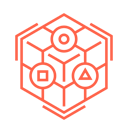 fanning out to development, staging, and production.
<div style="display:flex;gap:26px;flex-wrap:wrap;max-width:1120px;margin:0 auto;font-family:sans-serif;">
  <div style="flex:1 1 440px;min-width:340px;">
    <div style="border:2px dashed #FF5F46;border-radius:8px;padding:12px 16px;font-weight:700;font-size:14.5pt;color:#0b2026;margin-bottom:16px;">How to write code once, and then deploy to multiple environments easily?</div>
    <div style="font-size:15pt;font-weight:700;color:#0b2026;margin-bottom:12px;">What if we could&hellip;</div>
    <div style="background:#F9F7F4;border-left:6px solid #FF5F46;border-radius:0 8px 8px 0;padding:14px 18px;margin-bottom:12px;font-size:14pt;color:#0b2026;box-shadow:0 2px 8px rgba(27,49,57,0.06);">Co-version <mark>code with all configurations</mark> in a simple, easy-to-understand format like <mark>YAML</mark>?</div>
    <div style="background:#F9F7F4;border-left:6px solid #FF5F46;border-radius:0 8px 8px 0;padding:14px 18px;margin-bottom:12px;font-size:14pt;color:#0b2026;box-shadow:0 2px 8px rgba(27,49,57,0.06);">Define Databricks resources using <mark>existing REST API parameters</mark>?</div>
    <div style="background:#F9F7F4;border-left:6px solid #FF5F46;border-radius:0 8px 8px 0;padding:14px 18px;margin-bottom:12px;font-size:14pt;color:#0b2026;box-shadow:0 2px 8px rgba(27,49,57,0.06);">Ensure <mark>user isolation</mark> during deployment?</div>
    <div style="background:#F9F7F4;border-left:6px solid #FF5F46;border-radius:0 8px 8px 0;padding:14px 18px;margin-bottom:12px;font-size:14pt;color:#0b2026;box-shadow:0 2px 8px rgba(27,49,57,0.06);">Specify <mark>environment-based overrides and variables</mark>?</div>
  </div>
  <div style="flex:1 1 360px;min-width:300px;">
    <div style="text-align:center;margin-bottom:8px;">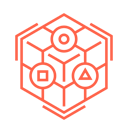</div>
    <div style="border:2px solid #FF5F46;border-radius:8px;padding:12px;text-align:center;font-size:13.5pt;color:#0b2026;">Deploy to <b>assets</b> and <b>configuration</b> settings to multiple environments</div>
    <div style="display:grid;grid-template-columns:1fr 1fr 1fr;text-align:center;color:#FF5F46;font-size:26pt;line-height:0.9;margin:2px 0 6px 0;"><div>&darr;</div><div>&darr;</div><div>&darr;</div></div>
    <div style="display:grid;grid-template-columns:1fr 1fr 1fr;gap:10px;">
      <div style="background:#FBE3E0;border-radius:6px;padding:10px;font-size:12.5pt;color:#0b2026;">
  <div style="display:flex;align-items:center;gap:6px;font-weight:700;margin-bottom:6px;">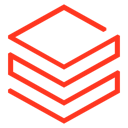 development</div>
  <div style="background:#F6A192;border-radius:4px;padding:5px;text-align:center;font-weight:700;margin-bottom:6px;">Databricks Assets</div>
  <div style="background:rgba(255,255,255,0.55);border-radius:5px;padding:8px 10px;">
    <div style="font-weight:700;margin-bottom:3px;">Dev config:</div>
    <ul style="margin:0;padding-left:16px;"><li>Single node</li><li>Run as user</li><li>Use dev data and environment</li></ul>
  </div>
</div>
      <div style="background:#FBEBCD;border-radius:6px;padding:10px;font-size:12.5pt;color:#0b2026;">
  <div style="display:flex;align-items:center;gap:6px;font-weight:700;margin-bottom:6px;">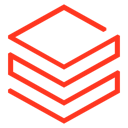 staging</div>
  <div style="background:#F6A192;border-radius:4px;padding:5px;text-align:center;font-weight:700;margin-bottom:6px;">Databricks Assets</div>
  <div style="background:rgba(255,255,255,0.55);border-radius:5px;padding:8px 10px;">
    <div style="font-weight:700;margin-bottom:3px;">Staging config:</div>
    <ul style="margin:0;padding-left:16px;"><li>Serverless</li><li>Run as service principal</li><li>Use staging data and environment</li></ul>
  </div>
</div>
      <div style="background:#D9EAD8;border-radius:6px;padding:10px;font-size:12.5pt;color:#0b2026;">
  <div style="display:flex;align-items:center;gap:6px;font-weight:700;margin-bottom:6px;">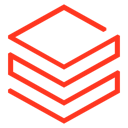 production</div>
  <div style="background:#F6A192;border-radius:4px;padding:5px;text-align:center;font-weight:700;margin-bottom:6px;">Databricks Assets</div>
  <div style="background:rgba(255,255,255,0.55);border-radius:5px;padding:8px 10px;">
    <div style="font-weight:700;margin-bottom:3px;">Production config:</div>
    <ul style="margin:0;padding-left:16px;"><li>Serverless</li><li>Run as service principal</li><li>Weekly schedule</li></ul>
  </div>
</div>
    </div>
  </div>
</div>
<style>.wish mark, mark { background:rgba(255,171,0,0.35); padding:1px 5px; border-radius:3px; }</style>

##### EXPAND FOR ADDITIONAL NOTES

<details>

_Speaker notes:_

- So, how can we simplify the CI/CD process for Databricks projects? How can we write code once for our project, then easily deploy it to multiple environments while modifying our configurations?
- What if we could co-version code with all configurations in a simple, easy-to-understand format like YAML? YAML is a human-readable format that organizes data using indentation and minimal syntax, making it easier to understand and edit than XML or JSON.
- Define Databricks resources using existing REST API parameters? This keeps parameters consistent with the other techniques.
- Ensure user isolation during deployment? This helps prevent users from interfering with each other's work during deployment.
- Specify environment-based overrides and variables? This lets us easily override values based on the target environment, ensuring flexibility for each environment.

</details>

### D2. Introducing Declarative Automation Bundles (DABs)!

<div style="font-family:sans-serif;max-width:1100px;margin:0 auto;text-align:center;">
  <div style="margin-bottom:14px;">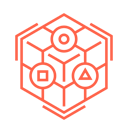</div>
  <div style="display:inline-block;border:2px solid #FF5F46;border-radius:8px;padding:16px 40px;font-size:22pt;font-weight:700;color:#0b2026;">Declarative Automation Bundles (DABs)</div>
  <div style="border:2px dashed #FF5F46;border-radius:8px;padding:18px 24px;margin-top:22px;font-size:15pt;color:#0b2026;line-height:1.5;">A tool to facilitate the adoption of software engineering best practices &mdash; including source control, code review, testing, and <b>continuous integration and delivery (CI/CD) &mdash; for your data and AI projects.</b></div>
</div>

##### EXPAND FOR ADDITIONAL NOTES

<details>

_Speaker notes:_

- Introducing Declarative Automation Bundles (or DABs)!
- A tool to facilitate the adoption of software engineering best practices, including source control, code review, testing, and continuous integration and delivery (CI/CD), for your data and AI projects.
- Moving forward, Databricks recommends DABs for creating, developing, deploying, and testing jobs and other Databricks resources as source code.

</details>

## E. Conclusion

- A Databricks project is made of **code**, **resources**, and an **execution environment**.
- The CI/CD journey promotes a project across **development, staging, and production**, driven by version control, with per-environment configuration.
- The UI, REST API/SDK, and Terraform can each orchestrate deployment, but each has real drawbacks for data engineering CI/CD.
- **Declarative Automation Bundles (DABs)** co-version code and configuration in YAML and deploy to multiple environments easily.

### Next Steps

In the next lecture, you will take a closer look at the fundamental components of a Declarative Automation Bundle.


&copy; 2026 Databricks, Inc. All rights reserved. Apache, Apache Spark, Spark, the Spark Logo, Apache Iceberg, Iceberg, and the Apache Iceberg logo are trademarks of the <a href="https://www.apache.org/" target="_blank">Apache Software Foundation</a>.<br/><br/><a href="https://databricks.com/privacy-policy" target="_blank">Privacy Policy</a> | <a href="https://databricks.com/terms-of-use" target="_blank">Terms of Use</a> | <a href="https://help.databricks.com/" target="_blank">Support</a>